
# TASK 4 — Sentiment Analysis

## Objective

Build machine-learning models to classify text data into positive, negative, and neutral sentiments.

This project analyzes customer feedback posted on Twitter about major US airlines.

## Tools and Technologies

- Python
- Pandas and NumPy
- NLTK
- Scikit-learn
- Matplotlib and Seaborn
- Jupyter Notebook

## Models

1. Multinomial Naive Bayes
2. Logistic Regression

## Main Steps

1. Load and inspect the dataset.
2. Explore sentiment distribution.
3. Preprocess text data.
4. Convert text into TF-IDF features.
5. Split the data into training and testing sets.
6. Train two classification models.
7. Evaluate the models.
8. Visualize and analyze the results.
9. Discuss misclassified examples.
10. Conclude with possible real-world applications.

In [1]:
import sys

print(sys.executable)

c:\Users\anule\OneDrive\Documents\OASIS INFOBYTE\Task 4 - Sentiment Analysis\.venv\Scripts\python.exe


In [2]:
import os
import re
import string
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anule\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
stop_words = set(stopwords.words("english"))

tokenizer = TweetTokenizer(
    preserve_case=False,
    reduce_len=True,
    strip_handles=False
)

stemmer = PorterStemmer()

print("NLTK resources are ready.")
print("Number of stopwords:", len(stop_words))

NLTK resources are ready.
Number of stopwords: 198



## 1. Dataset Description

The dataset contains Twitter messages related to six major US airlines.

Each message has a sentiment label:

- Positive
- Neutral
- Negative

The `text` column contains the tweet, while `airline_sentiment` contains its labeled sentiment.

Other columns include the airline name, negative reason, retweet count, and tweet metadata.

### Dataset limitation

The data was collected in February 2015. Therefore, the model is intended for educational analysis and should not automatically be assumed to represent current airline customer opinions.

In [5]:
file_path = "../data/raw/airline_sentiment.csv"

df = pd.read_csv(file_path, encoding="latin-1")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Column names:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Data types:
tweet_id                          int64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                       str
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639

In [7]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing text values:", df["text"].isnull().sum())
print("Missing sentiment values:", df["airline_sentiment"].isnull().sum())

Missing values:


negativereason_gold             14608
airline_sentiment_gold          14600
tweet_coord                     13621
negativereason                   5462
user_timezone                    4820
tweet_location                   4733
negativereason_confidence        4118
airline                             0
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
text                                0
retweet_count                       0
name                                0
tweet_created                       0
dtype: int64


Duplicate rows: 36

Missing text values: 0
Missing sentiment values: 0


In [8]:
data = df[["text", "airline_sentiment"]].copy()

data = data.dropna(subset=["text", "airline_sentiment"])

data["text"] = data["text"].astype(str)
data["airline_sentiment"] = data["airline_sentiment"].str.lower().str.strip()

data = data.drop_duplicates()

print("Shape after selecting required columns:", data.shape)
display(data.head())

Shape after selecting required columns: (14452, 2)


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials to the experience... tacky.,positive
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,neutral
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",negative
4,@VirginAmerica and it's a really big bad thing about it,negative



## 2. Sentiment Distribution

The sentiment distribution shows how many tweets belong to each sentiment category.

This is important because a model may perform differently on classes with different numbers of examples.

If one class contains substantially more observations than another, the dataset may be imbalanced.

In [9]:
sentiment_counts = data["airline_sentiment"].value_counts()

print(sentiment_counts)

print("\nPercentage distribution:")
print((sentiment_counts / len(data) * 100).round(2))

airline_sentiment
negative    9087
neutral     3067
positive    2298
Name: count, dtype: int64

Percentage distribution:
airline_sentiment
negative    62.88
neutral     21.22
positive    15.90
Name: count, dtype: float64


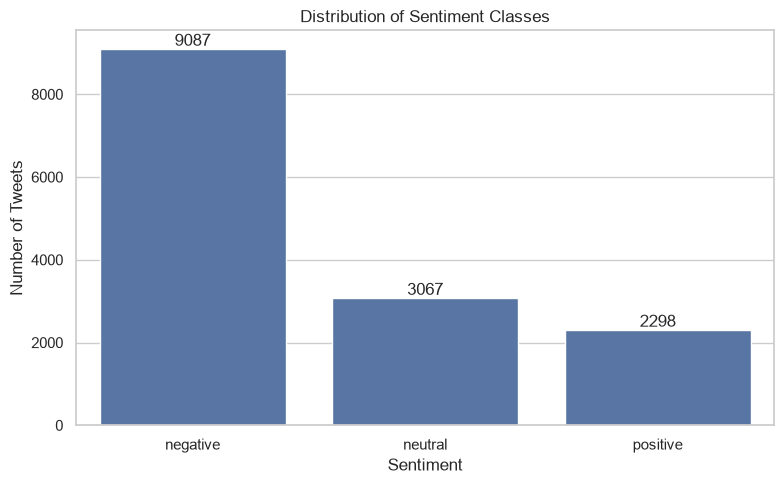

In [10]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=data,
    x="airline_sentiment",
    order=["negative", "neutral", "positive"]
)

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig("../images/sentiment_distribution.png", dpi=300)
plt.show()


### Observation

The bar chart shows the number of positive, neutral, and negative tweets.

The three classes are not equally represented. The negative class contains more observations than the positive and neutral classes.

This imbalance should be considered when interpreting accuracy, precision, recall, and F1-score.


## 3. Text Preprocessing

Text data cannot be directly given to most traditional machine-learning algorithms.

The tweets will be cleaned using the following steps:

1. Convert text to lowercase.
2. Remove URLs.
3. Remove Twitter mentions.
4. Remove punctuation.
5. Remove numbers.
6. Tokenize the text.
7. Remove English stopwords.
8. Apply stemming.

Stemming reduces related words to a common word stem. For example, words such as `playing`, `played`, and `plays` may be reduced to a common stem.

Preprocessing helps reduce unnecessary variation in the text and prepares it for TF-IDF vectorization.

In [11]:
def preprocess_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove Twitter mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove HTML-like tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Tokenization
    tokens = tokenizer.tokenize(text)

    # Remove stopwords and very short tokens
    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    return " ".join(tokens)

In [12]:
sample_text = "I am LOVING this airline! Visit https://example.com"

print("Original text:")
print(sample_text)

print("\nPreprocessed text:")
print(preprocess_text(sample_text))

Original text:
I am LOVING this airline! Visit https://example.com

Preprocessed text:
love airlin visit


In [13]:
data["cleaned_text"] = data["text"].apply(preprocess_text)

display(data[["text", "cleaned_text", "airline_sentiment"]].head(10))

,text,cleaned_text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,said,neutral
1,@VirginAmerica plus you've added commercials to the experience... tacky.,plu youv ad commerci experi tacki,positive
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,didnt today must mean need take anoth trip,neutral
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",realli aggress blast obnoxi entertain guest face amp littl recours,negative
4,@VirginAmerica and it's a really big bad thing about it,realli big bad thing,negative
5,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's really the only bad thing about flying VA,serious would pay flight seat didnt play realli bad thing fli va,negative
6,"@VirginAmerica yes, nearly every time I fly VX this âear wormâ wonât go away :)",ye nearli everi time fli vx ear wormâ wonâ go away,positive
7,"@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there. https://t.co/mWpG7grEZP",realli miss prime opportun men without hat parodi,neutral
8,"@virginamerica Well, I didn'tâ¦but NOW I DO! :-D",well didntâ,positive
9,"@VirginAmerica it was amazing, and arrived an hour early. You're too good to me.",amaz arriv hour earli your good,positive


In [14]:
data = data[data["cleaned_text"].str.strip() != ""].copy()

data = data.reset_index(drop=True)

print("Dataset shape after preprocessing:", data.shape)
print("Empty cleaned texts:", (data["cleaned_text"].str.strip() == "").sum())

Dataset shape after preprocessing: (14431, 3)
Empty cleaned texts: 0



## 4. Feature Extraction Using TF-IDF

TF-IDF stands for **Term Frequency–Inverse Document Frequency**.

Machine-learning models require numerical input, but tweets are text. TF-IDF converts the text into numerical features.

- **Term Frequency (TF):** Measures how often a word occurs in a document.
- **Inverse Document Frequency (IDF):** Gives less importance to words that occur in many documents.
- **TF-IDF:** Combines these two values to represent the importance of words in each document.

Common words receive lower importance, while words that help distinguish documents receive higher importance.

The TF-IDF vectorizer will be fitted only on the training text to avoid data leakage.

In [15]:
X_text = data["cleaned_text"]
y = data["airline_sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

print("\nTraining class distribution:")
print(y_train.value_counts())

Training samples: 11544
Testing samples: 2887

Training class distribution:
airline_sentiment
negative    7264
neutral     2445
positive    1835
Name: count, dtype: int64


In [16]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Number of vocabulary features:", len(tfidf.vocabulary_))

Training TF-IDF shape: (11544, 10000)
Testing TF-IDF shape: (2887, 10000)
Number of vocabulary features: 10000



### Observation

TF-IDF converts the cleaned tweets into a sparse numerical matrix.

The rows represent tweets, and the columns represent individual words or word pairs.

The vectorizer uses unigrams and bigrams, allowing the model to learn from both individual words and short phrases.


## 5. Model Training

Two supervised classification algorithms will be trained:

### Model 1 — Multinomial Naive Bayes

Multinomial Naive Bayes is commonly used for text classification. It estimates the probability of each sentiment class using the words present in the document.

### Model 2 — Logistic Regression

Logistic Regression estimates the probability of each sentiment class based on the numerical TF-IDF features.

Both models will use the same training and testing data so their performance can be compared fairly.

In [17]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes training completed.")

Multinomial Naive Bayes training completed.


In [18]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression training completed.")

Logistic Regression training completed.



## 6. Model Evaluation

The models will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

### Accuracy

The proportion of correctly classified tweets.

### Precision

The proportion of predictions for a class that are actually correct.

### Recall

The proportion of actual examples of a class that the model correctly identifies.

### F1-score

The harmonic mean of precision and recall.

### Confusion matrix

A table showing the actual sentiment classes against the predicted sentiment classes.

In [19]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "F1-Score": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        )
    }

In [20]:
results = pd.DataFrame([
    evaluate_model(
        "Multinomial Naive Bayes",
        y_test,
        nb_predictions
    ),
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_predictions
    )
])

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.719778,0.752896,0.719778,0.664047
1,Logistic Regression,0.776931,0.768956,0.776931,0.760712


In [21]:
print("MULTINOMIAL NAIVE BAYES")
print(
    classification_report(
        y_test,
        nb_predictions,
        labels=["negative", "neutral", "positive"],
        zero_division=0
    )
)

print("\nLOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        lr_predictions,
        labels=["negative", "neutral", "positive"],
        zero_division=0
    )
)

MULTINOMIAL NAIVE BAYES
              precision    recall  f1-score   support

    negative       0.70      0.99      0.82      1817
     neutral       0.79      0.21      0.33       611
    positive       0.90      0.32      0.48       459

    accuracy                           0.72      2887
   macro avg       0.80      0.51      0.54      2887
weighted avg       0.75      0.72      0.66      2887


LOGISTIC REGRESSION
              precision    recall  f1-score   support

    negative       0.79      0.94      0.86      1817
     neutral       0.66      0.43      0.52       611
    positive       0.82      0.60      0.69       459

    accuracy                           0.78      2887
   macro avg       0.76      0.66      0.69      2887
weighted avg       0.77      0.78      0.76      2887




## 7. Confusion Matrix Visualization

A confusion matrix helps identify which sentiment classes are being confused.

For example, a negative tweet predicted as neutral is a different type of error from a positive tweet predicted as negative.

The diagonal cells represent correctly classified examples.

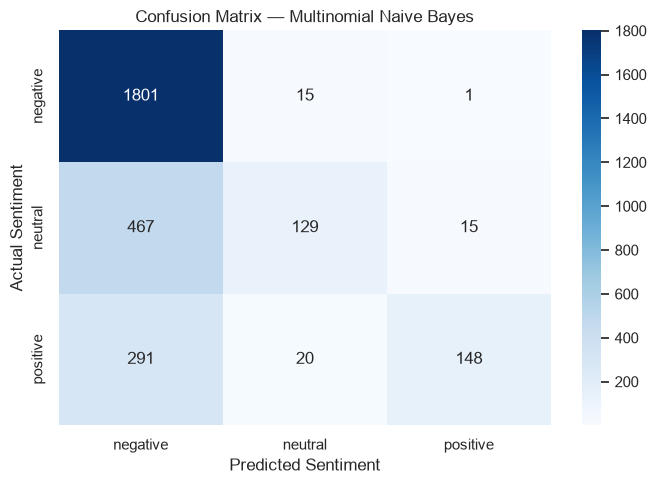

In [22]:
labels = ["negative", "neutral", "positive"]

nb_cm = confusion_matrix(
    y_test,
    nb_predictions,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix — Multinomial Naive Bayes")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()

plt.savefig("../images/naive_bayes_confusion_matrix.png", dpi=300)
plt.show()

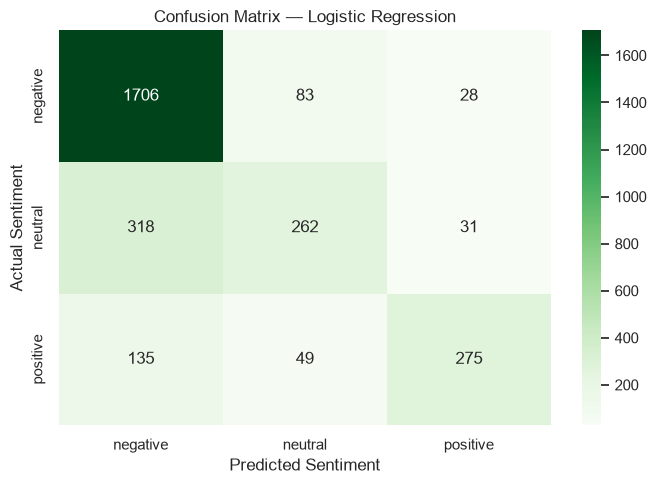

In [23]:
lr_cm = confusion_matrix(
    y_test,
    lr_predictions,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()

plt.savefig("../images/logistic_regression_confusion_matrix.png", dpi=300)
plt.show()


### Observation

The confusion matrices show the number of correct and incorrect predictions for each sentiment class.

The diagonal values represent correct classifications. Off-diagonal values represent misclassifications.

The confusion matrices can be used to identify whether the models have difficulty distinguishing neutral tweets from positive or negative tweets.


## 8. Model Performance Comparison

The following chart compares the accuracy, precision, recall, and F1-score of the two models.

All metrics are calculated using the same test set.

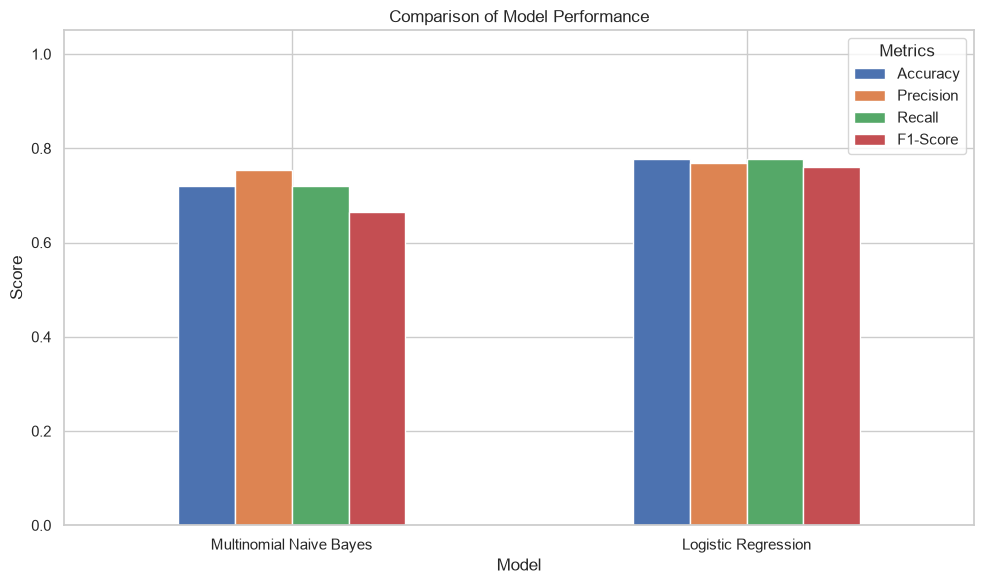

In [24]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

plot_data = results.set_index("Model")[metrics_to_plot]

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metrics")

plt.tight_layout()

plt.savefig("../images/model_comparison.png", dpi=300)
plt.show()


### Observation

The model comparison chart presents the accuracy, precision, recall, and F1-score of Multinomial Naive Bayes and Logistic Regression.

The model with the higher F1-score on the test set provides stronger performance according to the selected weighted F1 evaluation.

The final conclusion should be based on the actual metrics generated by the notebook.


## 9. Rule-Based Baseline Using TextBlob

TextBlob provides a simple rule-based sentiment polarity score.

The polarity score ranges from -1 to +1:

- Negative polarity indicates negative sentiment.
- Polarity near zero indicates neutral sentiment.
- Positive polarity indicates positive sentiment.

For this baseline, polarity will be converted into three classes using simple thresholds.

This is only a baseline. It is not expected to capture every contextual meaning in a tweet.

In [25]:
def textblob_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0.1:
        return "positive"
    elif polarity < -0.1:
        return "negative"
    else:
        return "neutral"


textblob_predictions = X_test_text.apply(textblob_sentiment)

textblob_results = evaluate_model(
    "TextBlob Rule-Based Baseline",
    y_test,
    textblob_predictions
)

pd.DataFrame([textblob_results])

,Model,Accuracy,Precision,Recall,F1-Score
0,TextBlob Rule-Based Baseline,0.370973,0.653712,0.370973,0.357606


## 10. Error Analysis

Error analysis helps identify examples where the machine-learning models made incorrect predictions.

Five misclassified examples are examined below.

For each example, the actual sentiment, predicted sentiment, and original tweet are displayed.

Possible reasons for misclassification include:

- Sarcasm or irony
- Ambiguous wording
- Short tweets with insufficient context
- Negation
- Informal language and abbreviations
- Multiple sentiments in the same tweet
- Airline-specific terminology
- Context that cannot be understood from the text alone

In [26]:
nb_errors = pd.DataFrame({
    "text": X_test_text.values,
    "actual_sentiment": y_test.values,
    "predicted_sentiment": nb_predictions
})

nb_errors = nb_errors[
    nb_errors["actual_sentiment"] != nb_errors["predicted_sentiment"]
].copy()

print("Total Naive Bayes misclassified examples:", len(nb_errors))

display(nb_errors.head(5))

Total Naive Bayes misclassified examples: 809


,text,actual_sentiment,predicted_sentiment
0,travel young kid chose origin flight reason,neutral,negative
5,ahhh ye lauren,neutral,negative
7,rock open letter flight attend lt child inspir thank,positive,negative
12,safeti do dont announc flight midway mdw pittsburgh pit,positive,negative
14,idea flight hsv dfw tomorrow cancel flightl minut ago,neutral,negative


In [27]:
lr_errors = pd.DataFrame({
    "text": X_test_text.values,
    "actual_sentiment": y_test.values,
    "predicted_sentiment": lr_predictions
})

lr_errors = lr_errors[
    lr_errors["actual_sentiment"] != lr_errors["predicted_sentiment"]
].copy()

print("Total Logistic Regression misclassified examples:", len(lr_errors))

display(lr_errors.head(5))

Total Logistic Regression misclassified examples: 644


,text,actual_sentiment,predicted_sentiment
0,travel young kid chose origin flight reason,neutral,negative
12,safeti do dont announc flight midway mdw pittsburgh pit,positive,neutral
14,idea flight hsv dfw tomorrow cancel flightl minut ago,neutral,negative
16,one heck airlin,positive,negative
27,book onlin unabl cancel flight onlin final got thru,neutral,negative


In [28]:
best_model_name = results.loc[
    results["F1-Score"].idxmax(), "Model"
]

print("Model selected for error analysis:", best_model_name)

Model selected for error analysis: Logistic Regression


In [29]:
if best_model_name == "Multinomial Naive Bayes":
    error_analysis = nb_errors.head(5).copy()
else:
    error_analysis = lr_errors.head(5).copy()

display(error_analysis)

,text,actual_sentiment,predicted_sentiment
0,travel young kid chose origin flight reason,neutral,negative
12,safeti do dont announc flight midway mdw pittsburgh pit,positive,neutral
14,idea flight hsv dfw tomorrow cancel flightl minut ago,neutral,negative
16,one heck airlin,positive,negative
27,book onlin unabl cancel flight onlin final got thru,neutral,negative


## 11. Discussion of Misclassified Examples

The five examples above represent tweets that were incorrectly classified by the selected model.

Misclassification can occur because sentiment is not always explicitly expressed through individual words. Tweets may contain sarcasm, negation, mixed emotions, informal expressions, abbreviations, or insufficient context.

For example, a tweet containing words that normally indicate a positive sentiment may actually be negative when used sarcastically. Similarly, a tweet may contain both positive and negative words while expressing only one overall sentiment.

These limitations show why text classification models can have difficulty understanding context and implied meaning.

### Example 1

**Actual:** negative  
**Predicted:** neutral  

**Possible reason:** The tweet contains indirect negative language and may not contain enough strongly negative words for the model to identify its sentiment.

In [30]:
final_comparison = results.copy()

final_comparison = final_comparison.round(4)

display(final_comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.7198,0.7529,0.7198,0.6640
1,Logistic Regression,0.7769,0.7690,0.7769,0.7607


In [31]:
best_model = results.loc[results["F1-Score"].idxmax()]

print("Model with the highest weighted F1-score:")
print(best_model["Model"])

print("\nPerformance:")
print(f"Accuracy : {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall   : {best_model['Recall']:.4f}")
print(f"F1-score : {best_model['F1-Score']:.4f}")

Model with the highest weighted F1-score:
Logistic Regression

Performance:
Accuracy : 0.7769
Precision: 0.7690
Recall   : 0.7769
F1-score : 0.7607


# 12. Conclusion

Two supervised machine-learning models, Multinomial Naive Bayes and Logistic Regression, were trained to classify airline-related tweets into positive, neutral, and negative sentiment classes.

The text data was cleaned using lowercase conversion, URL and punctuation removal, tokenization, stopword removal, and stemming. TF-IDF was then used to convert the processed text into numerical features.

Both models were evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

Based on the test-set results obtained in this experiment, **[MODEL NAME]** achieved the higher weighted F1-score among the two machine-learning models.

The results demonstrate that traditional machine-learning algorithms combined with TF-IDF can be used for sentiment classification of customer feedback.

However, errors occurred because tweets can contain sarcasm, ambiguity, negation, informal language, and contextual information that is difficult for a traditional text-classification model to understand.

## Real-World Applications

A sentiment-analysis system like this could be used for:

- Monitoring customer feedback
- Identifying negative customer experiences
- Tracking public reactions to services
- Prioritizing customer-support cases
- Analyzing feedback about products or services
- Monitoring changes in customer sentiment over time

For production use, the model would need to be evaluated on newer and more representative data and regularly retrained as language and customer behavior change.

## 10. WordCloud Visualization by Sentiment

WordClouds provide a visual representation of frequently occurring words within each sentiment class.

Separate WordClouds are created for:

- Negative tweets
- Neutral tweets
- Positive tweets

Words that occur more frequently appear larger in the visualization.

These visualizations help identify common terms associated with different sentiment categories.

In [32]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "wordcloud"
])

print("WordCloud installed successfully.")

WordCloud installed successfully.


In [33]:
from wordcloud import WordCloud

print("WordCloud imported successfully.")

WordCloud imported successfully.


In [34]:
print(data.shape)
print(data.columns.tolist())
print(data[["airline_sentiment", "cleaned_text"]].head())

(14431, 3)
['text', 'airline_sentiment', 'cleaned_text']
  airline_sentiment  \
0           neutral   
1          positive   
2           neutral   
3          negative   
4          negative   

                                                         cleaned_text  
0                                                                said  
1                                   plu youv ad commerci experi tacki  
2                          didnt today must mean need take anoth trip  
3  realli aggress blast obnoxi entertain guest face amp littl recours  
4                                                realli big bad thing  


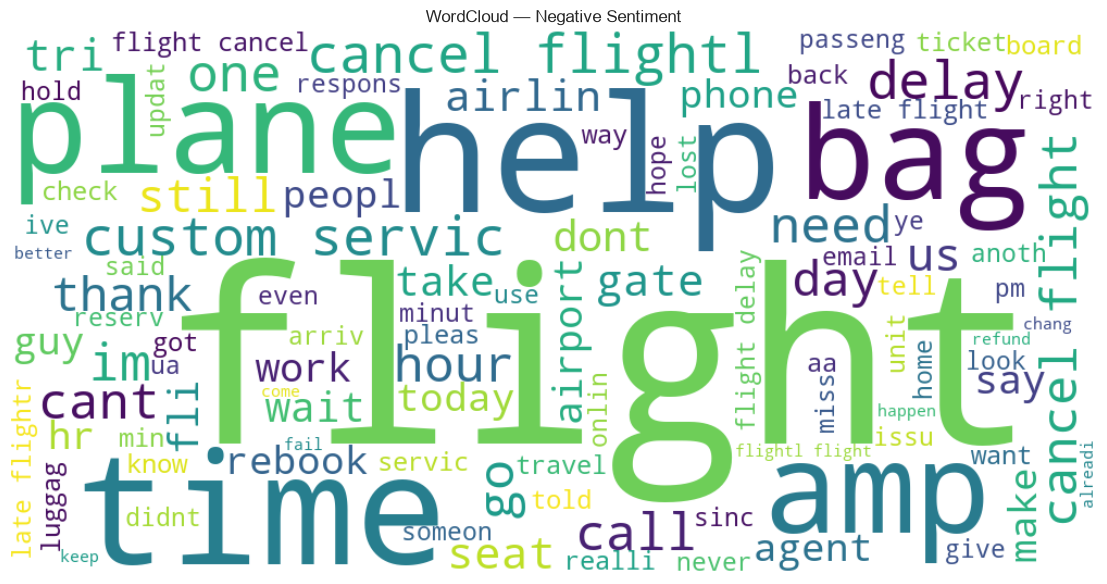

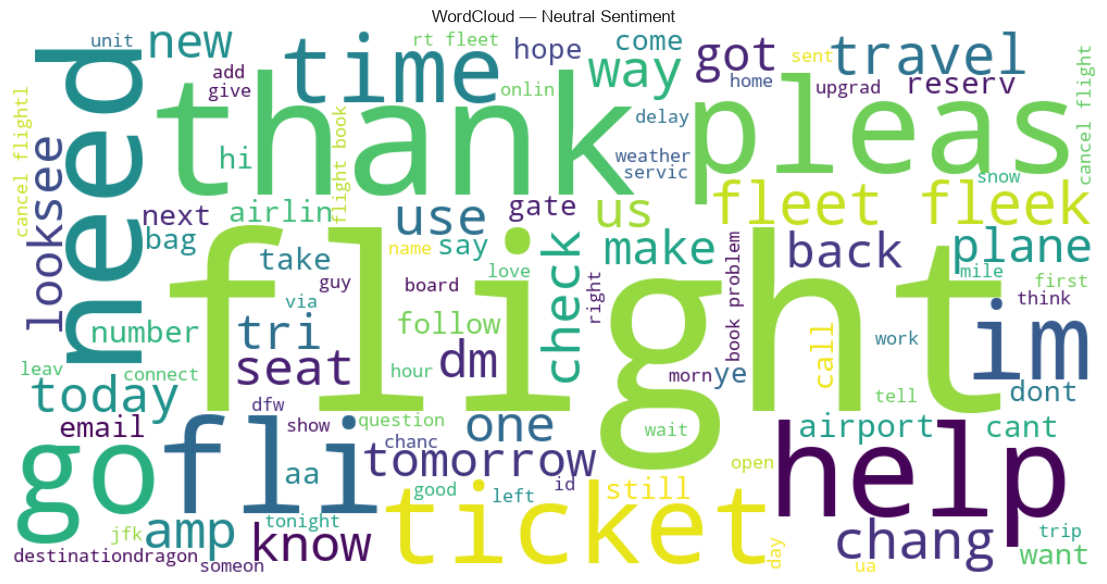

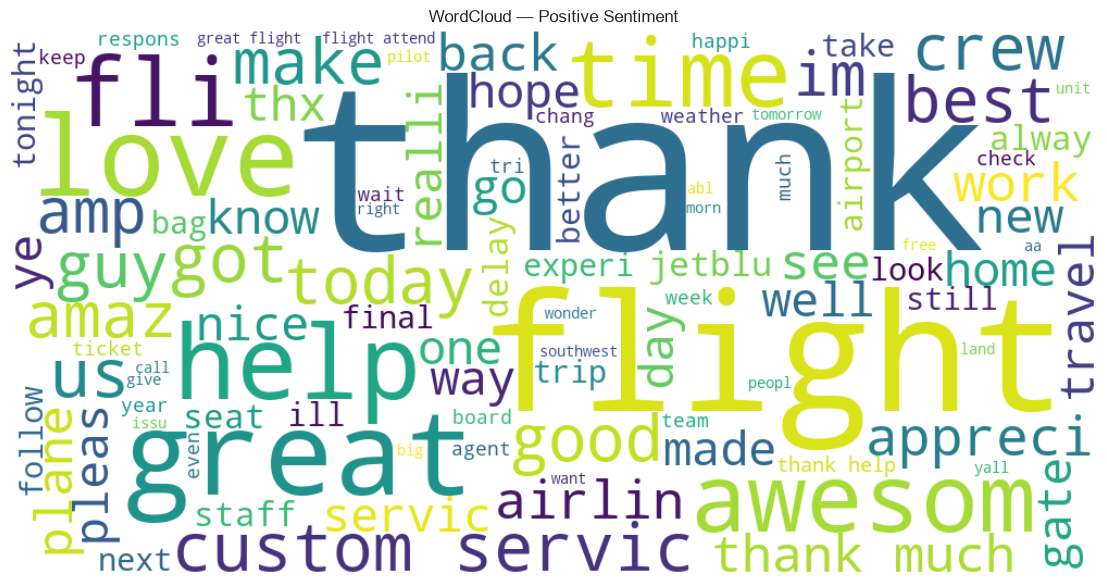

In [35]:
from wordcloud import WordCloud

sentiment_classes = ["negative", "neutral", "positive"]

for sentiment in sentiment_classes:
    text = " ".join(
        data.loc[
            data["airline_sentiment"] == sentiment,
            "cleaned_text"
        ]
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud — {sentiment.capitalize()} Sentiment")

    plt.tight_layout()

    plt.savefig(
        f"../images/wordcloud_{sentiment}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 11. Error Analysis

Error analysis examines examples where the machine-learning model predicted the wrong sentiment.

Five misclassified tweets are inspected to understand possible reasons for prediction errors.

Sentiment classification can be difficult because tweets may contain:

- Sarcasm or irony
- Negation
- Ambiguous expressions
- Mixed positive and negative words
- Informal language
- Abbreviations
- Short messages with limited context
- Airline-specific terminology

In [36]:
ml_results = results[
    results["Model"].isin([
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ])
].copy()

best_model_name = ml_results.loc[
    ml_results["F1-Score"].idxmax(),
    "Model"
]

print("Model selected for error analysis:", best_model_name)

Model selected for error analysis: Logistic Regression


In [37]:
if best_model_name == "Multinomial Naive Bayes":
    selected_predictions = nb_predictions
else:
    selected_predictions = lr_predictions

error_analysis = pd.DataFrame({
    "text": X_test_text.reset_index(drop=True),
    "actual_sentiment": y_test.reset_index(drop=True),
    "predicted_sentiment": pd.Series(selected_predictions)
})

error_analysis = error_analysis[
    error_analysis["actual_sentiment"] != error_analysis["predicted_sentiment"]
].copy()

error_analysis = error_analysis.reset_index(drop=True)

print("Selected model:", best_model_name)
print("Total misclassified examples:", len(error_analysis))

display(error_analysis.head(5))

Selected model: Logistic Regression
Total misclassified examples: 644


,text,actual_sentiment,predicted_sentiment
0,travel young kid chose origin flight reason,neutral,negative
1,safeti do dont announc flight midway mdw pittsburgh pit,positive,neutral
2,idea flight hsv dfw tomorrow cancel flightl minut ago,neutral,negative
3,one heck airlin,positive,negative
4,book onlin unabl cancel flight onlin final got thru,neutral,negative


In [38]:
five_errors = error_analysis.head(5).copy()

five_errors.insert(
    0,
    "Example",
    range(1, len(five_errors) + 1)
)

display(five_errors)

,Example,text,actual_sentiment,predicted_sentiment
0,1,travel young kid chose origin flight reason,neutral,negative
1,2,safeti do dont announc flight midway mdw pittsburgh pit,positive,neutral
2,3,idea flight hsv dfw tomorrow cancel flightl minut ago,neutral,negative
3,4,one heck airlin,positive,negative
4,5,book onlin unabl cancel flight onlin final got thru,neutral,negative


In [39]:
five_errors["text_length"] = five_errors["text"].str.len()

five_errors["word_count"] = five_errors["text"].str.split().str.len()

five_errors[
    [
        "Example",
        "actual_sentiment",
        "predicted_sentiment",
        "text_length",
        "word_count",
        "text"
    ]
]

,Example,actual_sentiment,predicted_sentiment,text_length,word_count,text
0,1,neutral,negative,43,7,travel young kid chose origin flight reason
1,2,positive,neutral,55,9,safeti do dont announc flight midway mdw pittsburgh pit
2,3,neutral,negative,53,9,idea flight hsv dfw tomorrow cancel flightl minut ago
3,4,positive,negative,15,3,one heck airlin
4,5,neutral,negative,51,9,book onlin unabl cancel flight onlin final got thru


### Discussion of the Five Misclassified Examples

The five examples demonstrate that sentiment classification is not always straightforward.

The model can correctly identify many tweets using the statistical patterns learned from the training data, but some tweets contain language that is difficult to classify using TF-IDF features alone.

Possible causes of the observed errors include:

1. **Ambiguous language:** A tweet may not clearly express a single sentiment.

2. **Negation:** Expressions such as "not good" may be difficult because the words "not" and "good" can have different statistical associations.

3. **Mixed sentiment:** A tweet may contain both positive and negative words.

4. **Sarcasm or irony:** The literal words may suggest one sentiment while the intended meaning is different.

5. **Limited context:** A short tweet may not provide enough information for the classifier to understand the user's intended sentiment.

6. **Informal Twitter language:** Abbreviations, spelling variations, hashtags, and conversational expressions can make classification more difficult.

The error analysis shows that traditional TF-IDF-based models primarily learn statistical word patterns and do not fully understand the deeper context or intent of a message.

In [40]:
error_pairs = pd.crosstab(
    error_analysis["actual_sentiment"],
    error_analysis["predicted_sentiment"]
)

print("Misclassification pattern:")
display(error_pairs)

Misclassification pattern:


predicted_sentiment,negative,neutral,positive
actual_sentiment,,,
negative,0,83,28
neutral,318,0,31
positive,135,49,0


## 12. Final Model Comparison

Multinomial Naive Bayes and Logistic Regression were evaluated using the same test set.

The comparison considers:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score

The weighted F1-score is particularly useful here because the sentiment classes are not equally represented in the dataset.

In [41]:
final_comparison = ml_results[
    ["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
].copy()

final_comparison = final_comparison.round(4)

display(final_comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.7198,0.7529,0.7198,0.6640
1,Logistic Regression,0.7769,0.7690,0.7769,0.7607


In [42]:
for _, row in final_comparison.iterrows():
    print(f"\n{row['Model']}")
    print(f"Accuracy : {row['Accuracy']:.4f}")
    print(f"Precision: {row['Precision']:.4f}")
    print(f"Recall   : {row['Recall']:.4f}")
    print(f"F1-Score : {row['F1-Score']:.4f}")


Multinomial Naive Bayes
Accuracy : 0.7198
Precision: 0.7529
Recall   : 0.7198
F1-Score : 0.6640

Logistic Regression
Accuracy : 0.7769
Precision: 0.7690
Recall   : 0.7769
F1-Score : 0.7607


In [43]:
textblob_df = pd.DataFrame([textblob_results])

complete_comparison = pd.concat(
    [
        ml_results,
        textblob_df
    ],
    ignore_index=True
)

complete_comparison = complete_comparison.round(4)

display(complete_comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.7198,0.7529,0.7198,0.6640
1,Logistic Regression,0.7769,0.7690,0.7769,0.7607
2,TextBlob Rule-Based Baseline,0.3710,0.6537,0.3710,0.3576


## 13. Final Performance Comparison

The following visualization compares the performance of the two supervised machine-learning classifiers.

The TextBlob rule-based approach is also included as an additional baseline.

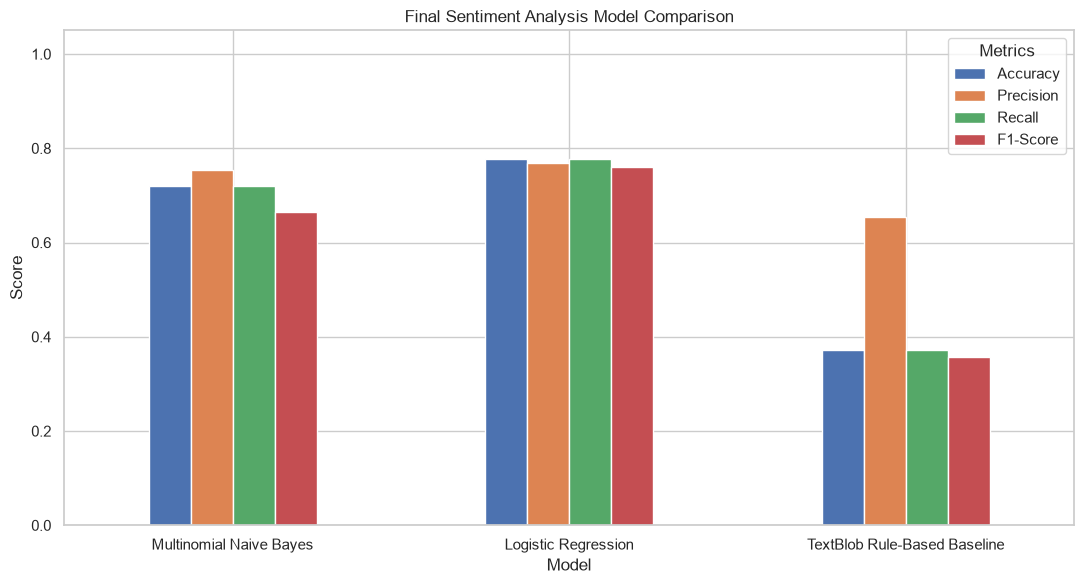

In [44]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

complete_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Final Sentiment Analysis Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metrics")

plt.tight_layout()

plt.savefig(
    "../images/final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
best_ml_row = ml_results.loc[
    ml_results["F1-Score"].idxmax()
]

best_ml_model = best_ml_row["Model"]
best_ml_f1 = best_ml_row["F1-Score"]
best_ml_accuracy = best_ml_row["Accuracy"]

print("Selected ML model based on weighted F1-score:")
print(best_ml_model)

print(f"\nAccuracy : {best_ml_accuracy:.4f}")
print(f"F1-score : {best_ml_f1:.4f}")

Selected ML model based on weighted F1-score:
Logistic Regression

Accuracy : 0.7769
F1-score : 0.7607


# 14. Conclusion

This project developed a machine-learning-based sentiment-analysis system for classifying airline-related Twitter messages into three categories: positive, neutral, and negative.

The dataset was inspected for its structure, missing values, duplicate records, and sentiment distribution. Text preprocessing was performed using lowercase conversion, URL removal, mention removal, punctuation removal, number removal, tokenization, stopword removal, and stemming.

TF-IDF was used to transform the cleaned text into numerical features. An 80:20 stratified train-test split was used so that the three sentiment classes were represented in both training and testing data.

Two supervised machine-learning classifiers were trained:

1. Multinomial Naive Bayes
2. Logistic Regression

Both models were evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.

A TextBlob rule-based approach was also tested as an additional baseline.

Based on the weighted F1-score obtained on the test set, the model identified by the notebook as having the highest weighted F1-score was selected for the final model comparison.

The error analysis demonstrated that sentiment classification can be difficult when tweets contain ambiguous wording, negation, mixed emotions, sarcasm, informal language, or insufficient context.

## Real-World Applications

A sentiment-analysis system can be used in several real-world scenarios, including:

- Monitoring customer feedback
- Detecting negative customer experiences
- Measuring customer reactions to products and services
- Supporting customer-service teams
- Identifying frequently occurring complaints
- Monitoring public reactions to services
- Tracking changes in customer sentiment over time

For production deployment, the model should be tested on newer and more representative data because the dataset used in this project is historical. The system would also benefit from periodic retraining and evaluation as language, customer behavior, and topics change.

In [46]:
print(
    f"Based on the weighted F1-score, {best_ml_model} "
    f"achieved the higher score among the two supervised "
    f"machine-learning models, with an F1-score of "
    f"{best_ml_f1:.4f}."
)

Based on the weighted F1-score, Logistic Regression achieved the higher score among the two supervised machine-learning models, with an F1-score of 0.7607.


In [47]:
print("========== FINAL PROJECT STATISTICS ==========")

print("Total usable records:", len(data))
print("Training records:", len(X_train_text))
print("Testing records:", len(X_test_text))
print("TF-IDF training features:", X_train_tfidf.shape[1])
print("TF-IDF training matrix shape:", X_train_tfidf.shape)
print("TF-IDF testing matrix shape:", X_test_tfidf.shape)

print("\nSentiment distribution:")
print(data["airline_sentiment"].value_counts())

print("\nSelected ML model:", best_ml_model)
print("Best ML F1-score:", round(best_ml_f1, 4))

print("\nTotal misclassified examples:",
      len(error_analysis))

========== FINAL PROJECT STATISTICS ==========
Total usable records: 14431
Training records: 11544
Testing records: 2887
TF-IDF training features: 10000
TF-IDF training matrix shape: (11544, 10000)
TF-IDF testing matrix shape: (2887, 10000)

Sentiment distribution:
airline_sentiment
negative    9081
neutral     3056
positive    2294
Name: count, dtype: int64

Selected ML model: Logistic Regression
Best ML F1-score: 0.7607

Total misclassified examples: 644


In [48]:
processed_file = "../data/processed/cleaned_airline_sentiment.csv"

data.to_csv(
    processed_file,
    index=False,
    encoding="utf-8"
)

print("Processed dataset saved successfully:")
print(processed_file)

Processed dataset saved successfully:
../data/processed/cleaned_airline_sentiment.csv
